### This notebook deals with EDA on the dataset.
We will perform EDA in 4 phases which are :
- 1. Univariate Analysis On Both Numerical and Categorical Columns
- 2. Relationship Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import math

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "grid.alpha": 0.3,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False
})

In [2]:
# load data

df = pd.read_csv('D:/Study/IFRS-9-Complient-Risk-Analysis-modelling/data/merged_dataset.csv')
df.replace(-99999 , np.nan , inplace = True)
print(df.shape)

(51336, 87)


### UNIVARIATE ANALYSIS

**1. Numerical Columns**

In [3]:
num_cols = df.select_dtypes(include=('number')).columns.to_list()
print(num_cols[:5])

['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M']


### 1.1 Basic Statistics 

In [4]:
def basic_summary(df, col):
    print("=" * 60)
    print(f"Column : {col}")
    print("=" * 60)

    print(f"Mean               : {df[col].mean():.2f}")
    print(f"Median             : {df[col].median():.2f}")
    print(f"Standard Deviation : {df[col].std():.2f}")
    print(f"Skewness           : {df[col].skew():.2f}")
    print(f"Kurtosis           : {df[col].kurtosis():.2f}")
    print()

for col in num_cols:
    basic_summary(df, col)

Column : PROSPECTID
Mean               : 25668.50
Median             : 25668.50
Standard Deviation : 14819.57
Skewness           : 0.00
Kurtosis           : -1.20

Column : Total_TL
Mean               : 4.86
Median             : 2.00
Standard Deviation : 7.18
Skewness           : 5.81
Kurtosis           : 68.63

Column : Tot_Closed_TL
Mean               : 2.77
Median             : 1.00
Standard Deviation : 5.94
Skewness           : 7.41
Kurtosis           : 108.99

Column : Tot_Active_TL
Mean               : 2.09
Median             : 1.00
Standard Deviation : 2.29
Skewness           : 2.89
Kurtosis           : 15.84

Column : Total_TL_opened_L6M
Mean               : 0.74
Median             : 0.00
Standard Deviation : 1.30
Skewness           : 3.42
Kurtosis           : 20.66

Column : Tot_TL_closed_L6M
Mean               : 0.43
Median             : 0.00
Standard Deviation : 0.99
Skewness           : 4.45
Kurtosis           : 34.20

Column : pct_tl_open_L6M
Mean               : 0.18
Medi

### 1.2 Histogram + Boxplot Distribution

In [19]:

n_cols = 2                               # Histogram | Boxplot
n_rows = len(num_cols)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows),
    gridspec_kw={"width_ratios": [3, 1]}
)

# Handle case when only one numeric column exists
if n_rows == 1:
    axes = [axes]

for i, col in enumerate(num_cols):

    # Histogram
    axes[i][0].hist(df[col].dropna(), bins=30,
                    edgecolor="black", alpha=0.8)
    axes[i][0].set_title(f"{col} Distribution", fontsize=12, fontweight="bold")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Frequency")
    axes[i][0].grid(alpha=0.3)

    # Boxplot
    axes[i][1].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="skyblue"),
        medianprops=dict(color="red", linewidth=2)
    )
    axes[i][1].set_title(f"{col} Boxplot", fontsize=12, fontweight="bold")
    axes[i][1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Most of the columns are heavily Right skewed -> We must use log transformed values later on in the project.
- Some of the numerical columns are not continuous but discrete, so we must look if it needs any processing.

### This tells us about
- DataTypes of the columns
- Unique values in the columns to differentiate -> categorical and numerical cols

In [5]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Unique %": round(df.nunique() / len(df) * 100, 2)
})

summary.sort_values("Unique Values")

,Data Type,Unique Values,Unique %
MARITALSTATUS,object,2,0.00
PL_Flag,int64,2,0.00
CC_Flag,int64,2,0.00
GL_Flag,int64,2,0.00
HL_Flag,int64,2,0.00
...,...,...,...
pct_currentBal_all_TL,float64,1528,2.98
time_since_recent_enq,float64,2381,4.64
time_since_recent_payment,float64,2434,4.74
max_unsec_exposure_inPct,float64,8974,17.48


### 2. Categorical Columns

### 2.1. Basic Summary

In [12]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

cat_summary = pd.DataFrame({
    "Unique Categories": df[cat_cols].nunique(),
    "Missing Values": df[cat_cols].isnull().sum(),
    "Missing (%)": (df[cat_cols].isnull().mean() * 100).round(2),
    "Mode": df[cat_cols].mode().iloc[0],
    "Mode Frequency": df[cat_cols].apply(lambda x: x.value_counts(dropna=True).iloc[0]),
    "Mode (%)": df[cat_cols].apply(
        lambda x: round(x.value_counts(normalize=True, dropna=True).iloc[0] * 100, 2)
    )
})
cat_summary["Cardinality"] = cat_summary["Unique Categories"].apply(
    lambda x: (
        "Binary" if x == 2 else
        "Low" if x <= 10 else
        "Medium" if x <= 30 else
        "High"
    )
)

cat_summary

,Unique Categories,Missing Values,Missing (%),Mode,Mode Frequency,Mode (%),Cardinality
MARITALSTATUS,2,0,0.0,Married,37752,73.54,Binary
EDUCATION,7,0,0.0,GRADUATE,16673,32.48,Low
GENDER,2,0,0.0,M,45245,88.14,Binary
last_prod_enq2,6,0,0.0,others,20831,40.58,Low
first_prod_enq2,6,0,0.0,others,28120,54.78,Low
Approved_Flag,4,0,0.0,P2,32199,62.72,Low


- Cardinality will help us in encoding the data:
- For binary, we will use LabelEncoding
- For Low Cardinality, we can use OneHotEncoding

### 2.2. Frequency tables

In [6]:
cat_cols = df.select_dtypes(include=('object')).columns.to_list()
print(cat_cols)

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


In [10]:
def frequency_table(cols):
    print("=" * 60)
    print(f"Column : {col}")
    print("=" * 60)

    print(df[cols].value_counts(ascending=False))
    print()

for col in cat_cols:
    frequency_table(col)


Column : MARITALSTATUS
MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64

Column : EDUCATION
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64

Column : GENDER
GENDER
M    45245
F     6091
Name: count, dtype: int64

Column : last_prod_enq2
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64

Column : first_prod_enq2
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64

Column : Approved_Flag
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64



- **From this frequency table we can infer that:**
- 1. Target Column `Approved_Flag` is not balanced, most of the consumers are in P2 Category.
- 2. Same goes with `first_prod_enq2` and `last_prod_enq2` most of the products are in `others` category.
- 3. Column `GENDER` is highly imbalanced having Males -> `45245` and Females only `6091`.

### 2.3. Count Plots

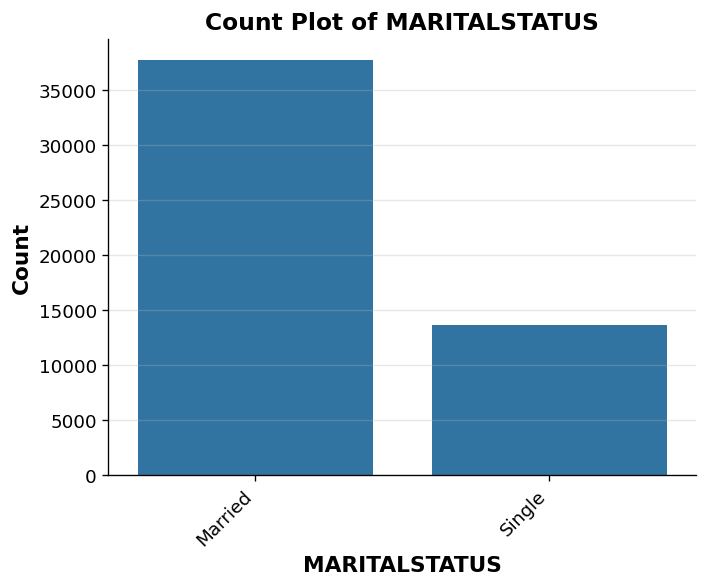

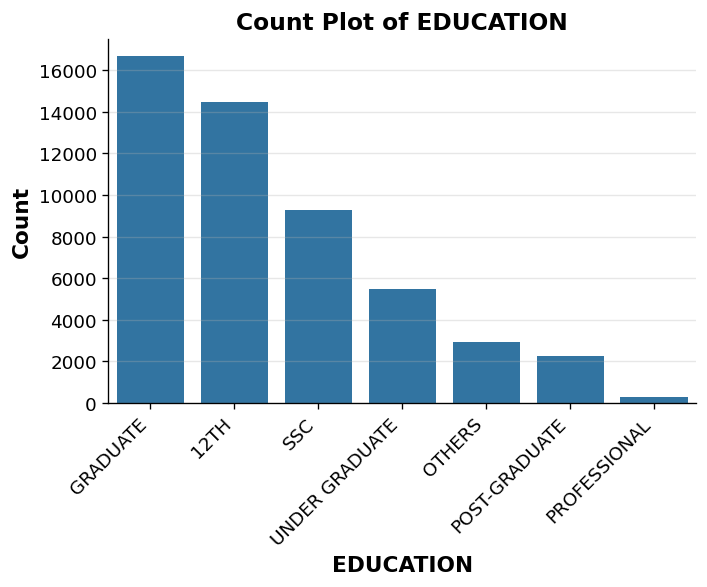

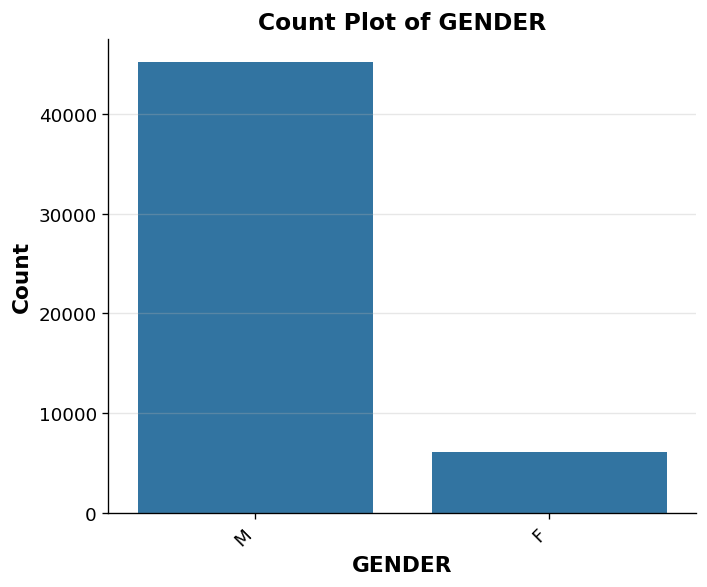

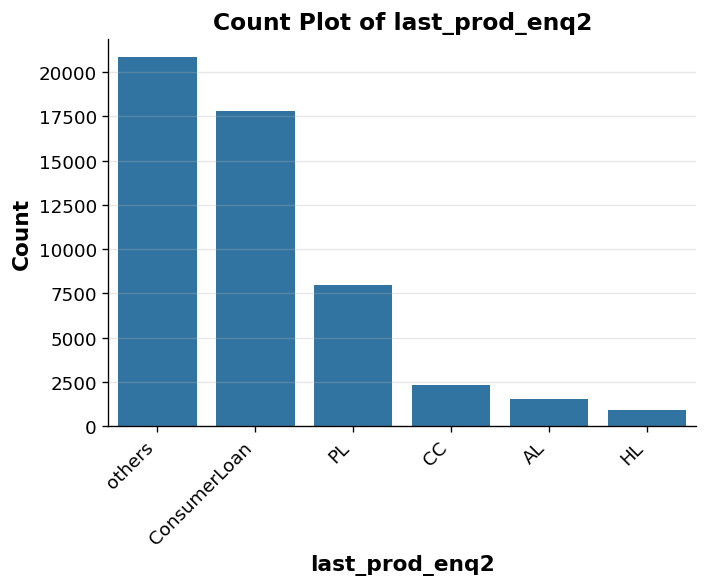

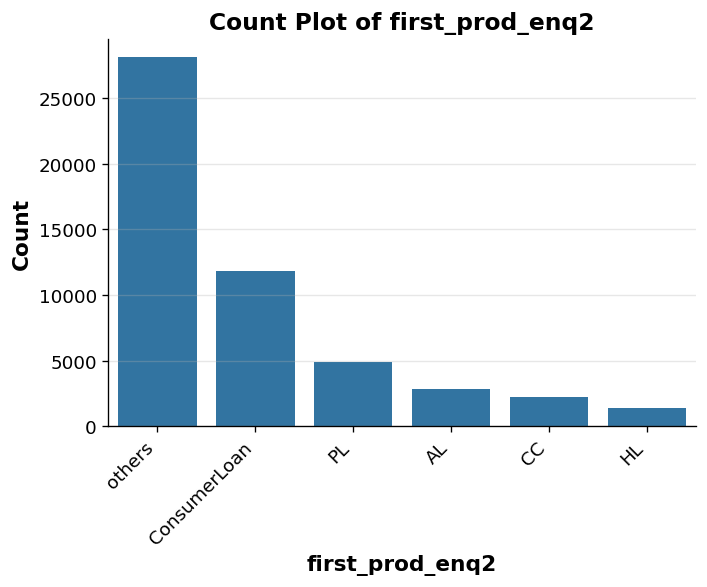

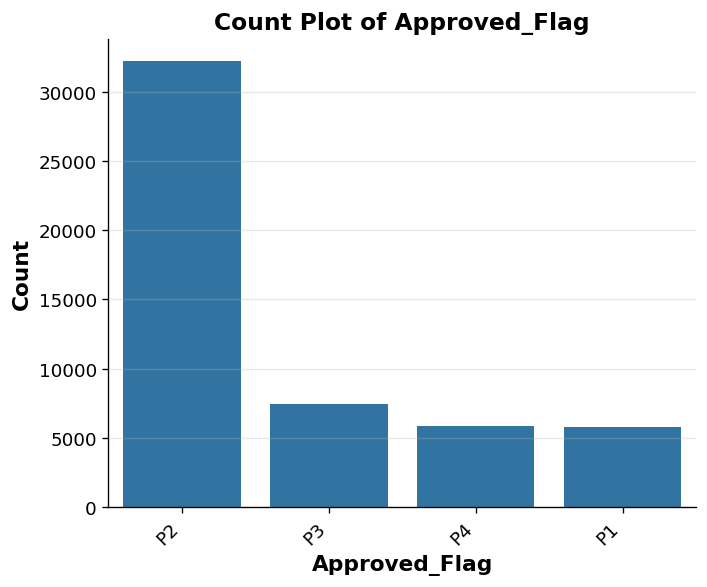

In [17]:
for col in cat_cols:

    plt.figure(figsize=(6, 5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

### 2.4. Rare Categories Analysis

In [18]:
rare_threshold = 5      # percentage

for col in cat_cols:

    print("="*70)
    print(f"Feature : {col}")
    print("="*70)

    category_pct = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    rare_categories = category_pct[category_pct < rare_threshold]

    if rare_categories.empty:
        print("No rare categories found.\n")
    else:
        print(rare_categories)
        print()

Feature : MARITALSTATUS
No rare categories found.

Feature : EDUCATION
EDUCATION
POST-GRADUATE    4.37
PROFESSIONAL     0.52
Name: proportion, dtype: float64

Feature : GENDER
No rare categories found.

Feature : last_prod_enq2
last_prod_enq2
CC    4.56
AL    2.94
HL    1.76
Name: proportion, dtype: float64

Feature : first_prod_enq2
first_prod_enq2
CC    4.26
HL    2.74
Name: proportion, dtype: float64

Feature : Approved_Flag
No rare categories found.



### 2.5. Category Balance Analysis

In [19]:
balance_summary = []

for col in cat_cols:

    proportions = df[col].value_counts(normalize=True)

    max_pct = round(proportions.iloc[0] * 100, 2)

    if max_pct < 60:
        balance = "Balanced"
    elif max_pct < 85:
        balance = "Moderately Imbalanced"
    else:
        balance = "Highly Imbalanced"

    balance_summary.append({
        "Feature": col,
        "Largest Category (%)": max_pct,
        "Balance": balance
    })

balance_summary = pd.DataFrame(balance_summary)

balance_summary

,Feature,Largest Category (%),Balance
0,MARITALSTATUS,73.54,Moderately Imbalanced
1,EDUCATION,32.48,Balanced
2,GENDER,88.14,Highly Imbalanced
3,last_prod_enq2,40.58,Balanced
4,first_prod_enq2,54.78,Balanced
5,Approved_Flag,62.72,Moderately Imbalanced


### 2.6. Business Interpretation 

**1. Business Interpretation – Univariate Analysis**
- `Dataset Overview`
The dataset contains `51,336` loan applicants and `87 features`, providing a rich representation of customer demographics, credit history, repayment behaviour, and loan characteristics.
The large sample size is suitable for developing a robust IFRS 9 Expected Credit Loss (ECL) model.
- `Numerical Variables`
Highly Right-Skewed Financial Variables
Most numerical variables (such as number of tradelines, balances, enquiries, overdue amounts, and exposures) exhibit strong `positive skewness`.
This indicates that the majority of customers have relatively low credit exposure, while a small proportion of borrowers carry significantly higher debt or credit activity.

**Business Interpretation**

- This is expected in retail lending portfolios, where only a small percentage of customers are highly leveraged.
- High-value observations are likely to represent customers with larger credit limits or multiple credit facilities rather than data errors.
- These customers may contribute disproportionately to the bank's credit risk and therefore deserve additional attention during risk modelling.
- Presence of Extreme Outliers
- Many variables contain extreme values, as reflected by the boxplots and high kurtosis.

**Business Interpretation**

In banking datasets, these observations often correspond to genuine high-risk or high-exposure customers.
Removing them indiscriminately could eliminate important default-risk signals.
Outliers should therefore be investigated carefully before deciding whether any treatment is necessary.
Discrete Numerical Features
Several numerical columns contain only a limited number of distinct values.

**Business Interpretation**

These variables behave more like ordered categories than continuous measurements.
During feature engineering, it may be beneficial to evaluate whether treating some of these variables as categorical improves model performance and interpretability.
Non-Normal Distributions
Very few numerical variables follow a symmetric distribution.

**Business Interpretation**

Many statistical models assume approximately normal distributions.
Appropriate transformations (such as logarithmic transformations where applicable) may improve model stability and predictive performance while reducing the influence of extreme observations.
Categorical Variables
Low Cardinality Features
Several categorical variables contain only two or a few unique values (for example, loan product flags and marital status).

**Business Interpretation**

These features are straightforward to encode and may provide meaningful information about customer characteristics or product ownership.
Binary indicators are often valuable predictors in credit risk models because they clearly distinguish customer segments.
Feature Diversity
The dataset contains a mixture of:
Customer demographic attributes
Credit bureau information
Loan portfolio characteristics
Payment behaviour
Credit exposure metrics
Product ownership indicators

**Business Interpretation**

This diversity suggests that the dataset captures multiple dimensions of borrower behaviour, making it suitable for estimating the components required in an IFRS 9 credit risk framework.
Data Quality
The placeholder value -99999 has been converted to missing values (NaN) before analysis.

**Business Interpretation**

This ensures that descriptive statistics and subsequent modelling are not distorted by artificial placeholder values.
Appropriate missing value treatment can now be performed based on the business meaning of each feature.